In [ ]:
%pip install 'chronos-forecasting[extras]>=2.2' 'matplotlib'

In [ ]:
%pip install 'chronos-forecasting[dev]>=2.2' matplotlib scipy
# Clone the repo and install in editable mode so you can modify source code
!git clone https://github.com/MiaYangM/chronos-forecasting.git
%pip install -e './chronos-forecasting[extras]'
%cd chronos-forecasting

Load Pipline

In [6]:
import sys
import os

# Get the current working directory
current_dir = os.getcwd()
print(f"Current working directory: {current_dir}")

# Assuming chronos-forecasting is cloned in /content/chronos-forecasting,
# the importable 'chronos' package is typically within a 'src' subdirectory.
# Add the 'src' directory to sys.path if it's not already there.
chronos_src_path = os.path.abspath(os.path.join(current_dir, 'src'))
if chronos_src_path not in sys.path:
    sys.path.insert(0, chronos_src_path)
    print(f"Added {chronos_src_path} to sys.path")

# Also ensure the top-level chronos-forecasting directory is in path for editable install
chronos_repo_path = os.path.abspath(current_dir)
if chronos_repo_path not in sys.path:
    sys.path.insert(0, chronos_repo_path)
    print(f"Added {chronos_repo_path} to sys.path")

print("sys.path after adjustments:")
for p in sys.path:
    print(p)


Current working directory: /content/chronos-forecasting
sys.path after adjustments:
/content/chronos-forecasting
/content/chronos-forecasting/src
/content
/env/python
/usr/lib/python312.zip
/usr/lib/python3.12
/usr/lib/python3.12/lib-dynload

/usr/local/lib/python3.12/dist-packages
/usr/lib/python3/dist-packages
/usr/local/lib/python3.12/dist-packages/IPython/extensions
/root/.ipython


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Now retry the import of chronos
try:
    from chronos import BaseChronosPipeline, Chronos2Pipeline
    print("Successfully imported chronos module.")

    # Re-initialize the pipeline if import is successful
    pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained(
        "amazon/chronos-2",
        device_map="cuda"   # or "cpu" if no GPU
    )
    print("Chronos2Pipeline initialized successfully.")
except ModuleNotFoundError:
    print("Failed to import chronos module even after path adjustment. Please check the 'chronos-forecasting' repository structure.")
except Exception as e:
    print(f"An error occurred during pipeline initialization: {e}")


Successfully imported chronos module.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/478M [00:00<?, ?B/s]

Chronos2Pipeline initialized successfully.


univariate forecasting (simplest case)

In [7]:
#Load data as a long-format pandas data frame
context_df = pd.read_csv("https://autogluon.s3.amazonaws.com/datasets/timeseries/m4_hourly/train.csv")
print("Input dataframe shape:", context_df.shape)
display(context_df.head())

Input dataframe shape: (353500, 3)


,item_id,timestamp,target
0,H1,1750-01-01 00:00:00,605.0
1,H1,1750-01-01 01:00:00,586.0
2,H1,1750-01-01 02:00:00,586.0
3,H1,1750-01-01 03:00:00,559.0
4,H1,1750-01-01 04:00:00,511.0


In [8]:
pred_df = pipeline.predict_df(context_df, prediction_length=24, quantile_levels=[0.1, 0.5, 0.9])

print("Output dataframe shape:", pred_df.shape)
display(pred_df.head())

Output dataframe shape: (9936, 7)


,item_id,timestamp,target_name,predictions,0.1,0.5,0.9
0,H1,1750-01-30 04:00:00,target,624.867981,611.385132,624.867981,638.598755
1,H1,1750-01-30 05:00:00,target,563.703125,546.655029,563.703125,578.665649
2,H1,1750-01-30 06:00:00,target,521.589844,505.747498,521.589844,537.950745
3,H1,1750-01-30 07:00:00,target,489.910706,473.671814,489.910706,508.854126
4,H1,1750-01-30 08:00:00,target,471.144470,452.199463,471.144470,491.050232


Forecasting with Covariates

In [9]:
# Energy price forecasting configuration
target = "target"  # Column name containing the values to forecast (energy prices)
prediction_length = 24  # Number of hours to forecast ahead
id_column = "id"  # Column identifying different time series (countries/regions)
timestamp_column = "timestamp"  # Column containing datetime information
timeseries_id = "DE"  # Specific time series to visualize (Germany)

# Load historical energy prices and past values of covariates
energy_context_df = pd.read_parquet(
    "https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/train.parquet"
)
energy_context_df[timestamp_column] = pd.to_datetime(energy_context_df[timestamp_column])
display(energy_context_df.head())

# Load future values of covariates
energy_test_df = pd.read_parquet(
    "https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/test.parquet"
)
energy_test_df[timestamp_column] = pd.to_datetime(energy_test_df[timestamp_column])
energy_future_df = energy_test_df.drop(columns=target)
display(energy_future_df.head())

,id,timestamp,target,Ampirion Load Forecast,PV+Wind Forecast
0,DE,2012-01-09 00:00:00,34.970001,16382.00,3569.527588
1,DE,2012-01-09 01:00:00,33.430000,15410.50,3315.274902
2,DE,2012-01-09 02:00:00,32.740002,15595.00,3107.307617
3,DE,2012-01-09 03:00:00,32.459999,16521.00,2944.620117
4,DE,2012-01-09 04:00:00,32.500000,17700.75,2897.149902


,id,timestamp,Ampirion Load Forecast,PV+Wind Forecast
0,DE,2017-12-12 00:00:00,20483.00,22284.005859
1,DE,2017-12-12 01:00:00,19849.75,22878.673828
2,DE,2017-12-12 02:00:00,19638.25,23632.283203
3,DE,2017-12-12 03:00:00,19895.25,24635.945312
4,DE,2017-12-12 04:00:00,20338.00,25584.935547


In [10]:
# Generate predictions with covariates
energy_pred_df = pipeline.predict_df(
    energy_context_df,
    future_df=energy_future_df,
    prediction_length=prediction_length,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column=id_column,
    timestamp_column=timestamp_column,
    target=target,
)
display(energy_pred_df.head())

,id,timestamp,target_name,predictions,0.1,0.5,0.9
0,DE,2017-12-12 00:00:00,target,22.242924,18.673725,22.242924,25.403454
1,DE,2017-12-12 01:00:00,target,19.525616,14.904280,19.525616,23.316599
2,DE,2017-12-12 02:00:00,target,17.415367,12.209051,17.415367,21.776979
3,DE,2017-12-12 03:00:00,target,16.979265,11.165123,16.979265,21.435223
4,DE,2017-12-12 04:00:00,target,18.058653,12.096769,18.058653,23.166643


In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# Visualization helper function
def plot_forecast(
    context_df: pd.DataFrame,
    pred_df: pd.DataFrame,
    test_df: pd.DataFrame,
    target_column: str,
    timeseries_id: str,
    id_column: str = "id",
    timestamp_column: str = "timestamp",
    history_length: int = 256,
    title_suffix: str = "",
):
    ts_context = context_df.query(f"{id_column} == @timeseries_id").set_index(timestamp_column)[target_column]
    ts_pred = pred_df.query(f"{id_column} == @timeseries_id and target_name == @target_column").set_index(
        timestamp_column
    )[["0.1", "predictions", "0.9"]]
    ts_ground_truth = test_df.query(f"{id_column} == @timeseries_id").set_index(timestamp_column)[target_column]

    last_date = ts_context.index.max()
    start_idx = max(0, len(ts_context) - history_length)
    plot_cutoff = ts_context.index[start_idx]
    ts_context = ts_context[ts_context.index >= plot_cutoff]
    ts_pred = ts_pred[ts_pred.index >= plot_cutoff]
    ts_ground_truth = ts_ground_truth[ts_ground_truth.index >= plot_cutoff]

    fig = plt.figure(figsize=(12, 3))
    ax = fig.gca()
    ts_context.plot(ax=ax, label=f"historical {target_column}", color="xkcd:azure")
    ts_ground_truth.plot(ax=ax, label=f"future {target_column} (ground truth)", color="xkcd:grass green")
    ts_pred["predictions"].plot(ax=ax, label="forecast", color="xkcd:violet")
    ax.fill_between(
        ts_pred.index,
        ts_pred["0.1"],
        ts_pred["0.9"],
        alpha=0.7,
        label="prediction interval",
        color="xkcd:light lavender",
    )
    ax.axvline(x=last_date, color="black", linestyle="--", alpha=0.5)

    ax.set_title(f"{target_column} forecast for {timeseries_id} {title_suffix}")

    # Make background transparent
    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)


    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)

    fig.show()

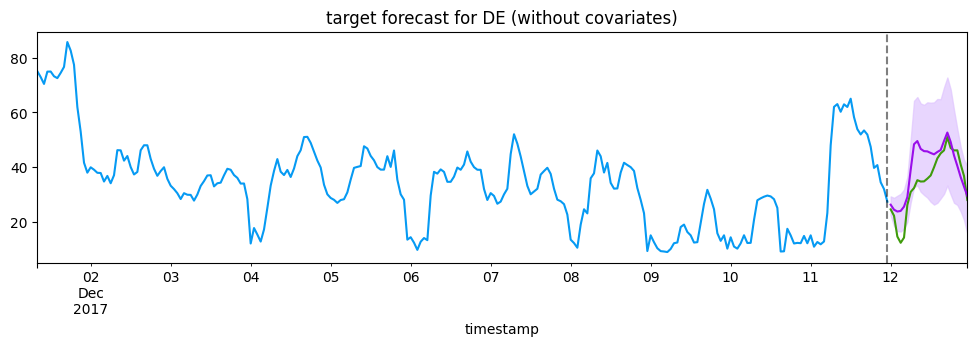

In [19]:
# Compare: forecast without covariates
energy_pred_no_cov_df = pipeline.predict_df(
    energy_context_df[[id_column, timestamp_column, target]],
    future_df=None,
    prediction_length=prediction_length,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column=id_column,
    timestamp_column=timestamp_column,
    target=target,
)

plot_forecast(
    energy_context_df,
    energy_pred_no_cov_df,
    energy_test_df,
    target_column=target,
    timeseries_id=timeseries_id,
    title_suffix="(without covariates)",
)

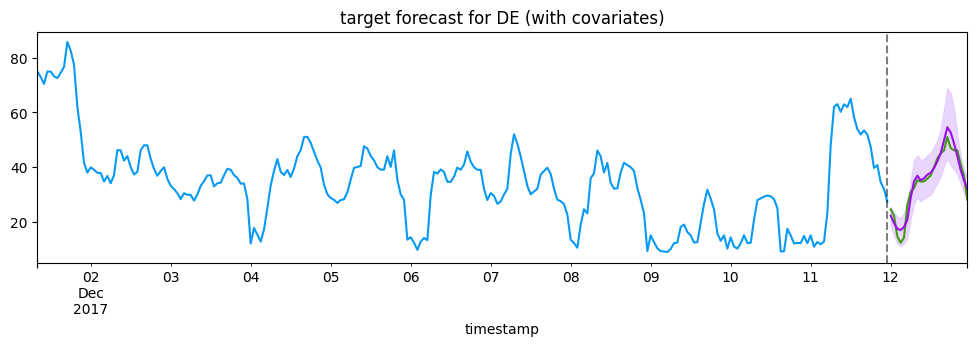

In [20]:
# Visualize forecast with covariates
plot_forecast(
    energy_context_df,
    energy_pred_df,
    energy_test_df,
    target_column=target,
    timeseries_id=timeseries_id,
    title_suffix="(with covariates)",
)

Retail Demand Forecasting
Forecast next quarter's weekly store sales using historical sales, historical customer footfall (Customers), and known covariates indicating store operation (Open), promotion periods (Promo), and holidays (SchoolHoliday, StateHoliday).

In [21]:
# Retail forecasting configuration
target = "Sales"  # Column name containing sales values to forecast
prediction_length = 13  # Number of days to forecast ahead
id_column = "id"  # Column identifying different products/stores
timestamp_column = "timestamp"  # Column containing datetime information
timeseries_id = "1"  # Specific time series to visualize (product/store ID)

# Load historical sales and past values of covariates
sales_context_df = pd.read_parquet("https://autogluon.s3.amazonaws.com/datasets/timeseries/retail_sales/train.parquet")
sales_context_df[timestamp_column] = pd.to_datetime(sales_context_df[timestamp_column])
display(sales_context_df.head())

# Load future values of covariates
sales_test_df = pd.read_parquet("https://autogluon.s3.amazonaws.com/datasets/timeseries/retail_sales/test.parquet")
sales_test_df[timestamp_column] = pd.to_datetime(sales_test_df[timestamp_column])
sales_future_df = sales_test_df.drop(columns=target)
display(sales_future_df.head())

,id,timestamp,Sales,Open,Promo,SchoolHoliday,StateHoliday,Customers
0,1,2013-01-13,32952.0,0.857143,0.714286,5.0,0.0,3918.0
1,1,2013-01-20,25978.0,0.857143,0.000000,0.0,0.0,3417.0
2,1,2013-01-27,33071.0,0.857143,0.714286,0.0,0.0,3862.0
3,1,2013-02-03,28693.0,0.857143,0.000000,0.0,0.0,3561.0
4,1,2013-02-10,35771.0,0.857143,0.714286,0.0,0.0,4094.0


,id,timestamp,Open,Promo,SchoolHoliday,StateHoliday
0,1,2015-05-03,0.714286,0.714286,0.0,1.0
1,1,2015-05-10,0.857143,0.714286,0.0,0.0
2,1,2015-05-17,0.714286,0.000000,0.0,1.0
3,1,2015-05-24,0.857143,0.714286,0.0,0.0
4,1,2015-05-31,0.714286,0.000000,0.0,1.0


In [22]:
# Generate predictions with covariates
sales_pred_df = pipeline.predict_df(
    sales_context_df,
    future_df=sales_future_df,
    prediction_length=prediction_length,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column=id_column,
    timestamp_column=timestamp_column,
    target=target,
)
display(sales_pred_df.head())

,id,timestamp,target_name,predictions,0.1,0.5,0.9
0,1,2015-05-03,Sales,28939.390625,25214.275391,28939.390625,32411.097656
1,1,2015-05-10,Sales,25541.919922,21921.324219,25541.919922,29191.931641
2,1,2015-05-17,Sales,23640.238281,20500.333984,23640.238281,26884.664062
3,1,2015-05-24,Sales,26778.261719,23318.355469,26778.261719,30162.820312
4,1,2015-05-31,Sales,22679.359375,19722.285156,22679.359375,25990.042969


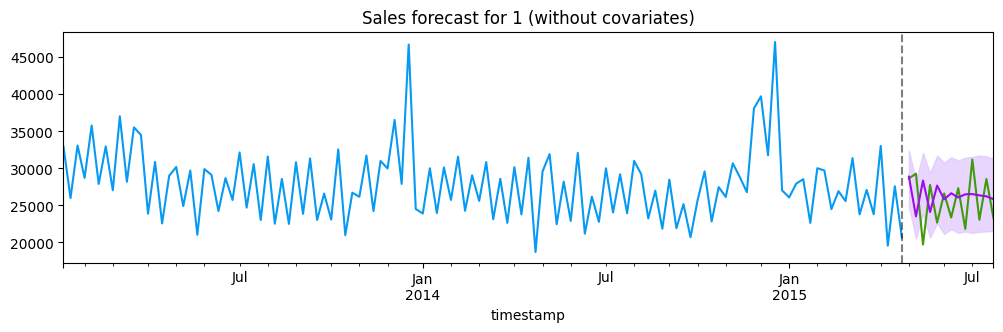

In [23]:
# Compare: forecast without covariates
sales_pred_no_cov_df = pipeline.predict_df(
    sales_context_df[[id_column, timestamp_column, target]],
    future_df=None,
    prediction_length=prediction_length,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column=id_column,
    timestamp_column=timestamp_column,
    target=target,
)

plot_forecast(
    sales_context_df,
    sales_pred_no_cov_df,
    sales_test_df,
    target_column=target,
    timeseries_id=timeseries_id,
    title_suffix="(without covariates)",
)

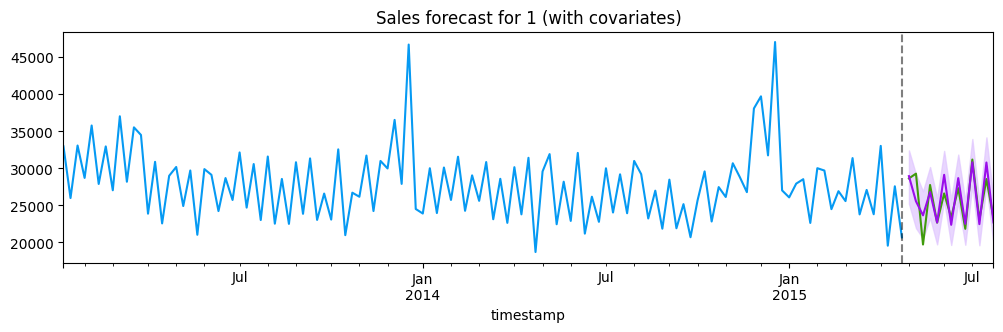

In [24]:
# Visualize forecast with covariates
plot_forecast(
    sales_context_df,
    sales_pred_df,
    sales_test_df,
    target_column=target,
    timeseries_id=timeseries_id,
    title_suffix="(with covariates)",
)

Low-level tensor API

In [ ]:
# Source: notebooks/chronos-2-quickstart.ipynb cells 14-17
# For use without pandas – e.g., when inputs are already numpy/torch arrays

# Univariate: batch of 32 series, each length 100
quantiles, mean = pipeline.predict_quantiles(
    np.random.randn(32, 1, 100),
    prediction_length=24,
    quantile_levels=[0.1, 0.5, 0.9],
)
# quantiles: list of tensors, each shape (1, 3, 24); mean: list of tensors (1, 24)
print("Shape per item:", quantiles[0].shape, mean[0].shape)

# With past + future covariates (dict API)
prediction_length = 64
inputs = [
    {
        "target": np.random.randn(200),
        "past_covariates": {"temp": np.random.randn(200)},
        "future_covariates": {"temp": np.random.randn(prediction_length)},
    }
    for _ in range(8)
]
quantiles, mean = pipeline.predict_quantiles(
    inputs, prediction_length=prediction_length, quantile_levels=[0.1, 0.5, 0.9]
)
print("With covariates shape:", quantiles[0].shape)

Shape per item: torch.Size([1, 24, 3]) torch.Size([1, 24])
With covariates shape: torch.Size([1, 64, 3])


 Cross-learning (joint prediction across items)

In [ ]:

# Chronos-2 unique feature: all items in the batch share information
pred_df_cross = pipeline.predict_df(
    context_df,
    prediction_length=24,
    quantile_levels=[0.1, 0.5, 0.9],
    cross_learning=True,  # enable cross-item attention
    batch_size=100,
)

In [ ]:
# Source: notebooks/chronos-2-quickstart.ipynb cells 18-19
# Requires [extras] (peft is installed but not used for full fine-tuning)

known_covariates = ["Open", "Promo", "SchoolHoliday", "StateHoliday"]
past_covariates  = ["Customers"]

sales_context_df = pd.read_parquet(
    "https://autogluon.s3.amazonaws.com/datasets/timeseries/retail_sales/train.parquet"
)
train_inputs = [
    {
        "target": g["Sales"].values,
        "past_covariates":   {c: g[c].values for c in past_covariates + known_covariates},
        "future_covariates": {c: None for c in known_covariates},  # mark as known-future
    }
    for _, g in sales_context_df.groupby("id")
]

finetuned_pipeline = pipeline.fit(
    inputs=train_inputs,
    prediction_length=13,
    num_steps=1000,
    learning_rate=1e-5,
    batch_size=32,
    logging_steps=100,
    # output_dir="chronos-2-finetuned/..."  # auto-set if None
)

Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss
100,0.656100
200,0.536500
300,0.507000
400,0.463300
500,0.458200
600,0.520300
700,0.462300
800,0.429800
900,0.442400
1000,0.498400


LoRA fine-tune on retail sales

In [ ]:
# Source: notebooks/chronos-2-quickstart.ipynb cell 21
# Requires peft (included in [extras])
lora_pipeline = pipeline.fit(
    inputs=train_inputs,
    prediction_length=13,
    num_steps=1000,
    learning_rate=1e-4,   # recommend higher LR for LoRA
    batch_size=32,
    finetune_mode="lora",
    # lora_config=None → uses default: r=8, alpha=16
    # target_modules: q,k,v,o projections + output_patch_embedding
    # Source: src/chronos/chronos2/pipeline.py lines 205-225
)

Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss
100,0.756800
200,0.617700
300,0.595300
400,0.541100
500,0.545600
600,0.604000
700,0.547100
800,0.514500
900,0.526500
1000,0.582700


Evaluation

In [ ]:
%pip install 'chronos-forecasting[dev]>=2.2' matplotlib scipy
# dev extra includes: gluonts[pro], datasets, typer, joblib, rich, fev
# Source: pyproject.toml lines 57-66

In [ ]:
!git clone https://github.com/MiaYangM/chronos-forecasting.git
%cd chronos-forecasting

fatal: destination path 'chronos-forecasting' already exists and is not an empty directory.
/content/chronos-forecasting


Smoke test: 7-dataset CI evaluation (Chronos-2)

In [ ]:
# Uses ci/evaluate/backtest_config.yaml (7 datasets: taxi_30min, ETTh,
# monash_covid_deaths, monash_nn5_weekly, monash_fred_md, monash_m3_quarterly,
# monash_tourism_yearly). Source: ci/evaluate/backtest_config.yaml
!python scripts/evaluation/evaluate.py chronos-2 \
    ci/evaluate/backtest_config.yaml \
    /tmp/chronos2-smoke-test.csv \
    --model-id "amazon/chronos-2" \
    --device cuda \
    --torch-dtype float32 \
    --batch-size 16

In [ ]:
import pandas as pd
df = pd.read_csv("/tmp/chronos2-smoke-test.csv")
display(df)

,dataset,model,MASE,WQL
0,ETTh,amazon/chronos-2,0.760812,0.073566
1,monash_covid_deaths,amazon/chronos-2,35.405557,0.039213
2,monash_fred_md,amazon/chronos-2,0.468734,0.019539
3,monash_m3_quarterly,amazon/chronos-2,1.162110,0.070462
4,monash_nn5_weekly,amazon/chronos-2,0.882498,0.081598
5,monash_tourism_yearly,amazon/chronos-2,3.666207,0.151526
6,taxi_30min,amazon/chronos-2,0.729660,0.223796


Full in-domain evaluation (15 datasets)

In [ ]:
# Takes 20 min on T4 GPU; results saved to scripts/evaluation/results/
!python scripts/evaluation/evaluate.py chronos-2 \
    scripts/evaluation/configs/in-domain.yaml \
    scripts/evaluation/results/chronos-2-in-domain.csv \
    --model-id "amazon/chronos-2" \
    --device cuda \
    --torch-dtype float32 \
    --batch-size 32

In [ ]:
import pandas as pd

evaluation_results_df = pd.read_csv('scripts/evaluation/results/chronos-2-in-domain.csv')
display(evaluation_results_df)

,dataset,model,MASE,WQL
0,electricity_15min,amazon/chronos-2,0.389305,0.069914
1,m4_daily,amazon/chronos-2,3.381546,0.022572
2,m4_hourly,amazon/chronos-2,0.810586,0.026533
3,m4_monthly,amazon/chronos-2,0.922428,0.092631
4,m4_weekly,amazon/chronos-2,2.114479,0.036970
5,monash_electricity_hourly,amazon/chronos-2,1.283775,0.081773
6,monash_electricity_weekly,amazon/chronos-2,1.729059,0.061576
7,monash_kdd_cup_2018,amazon/chronos-2,0.772155,0.296227
8,monash_london_smart_meters,amazon/chronos-2,0.681135,0.310725
9,monash_pedestrian_counts,amazon/chronos-2,0.285274,0.202817


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reset pandas display options to default for better plotting behavior
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

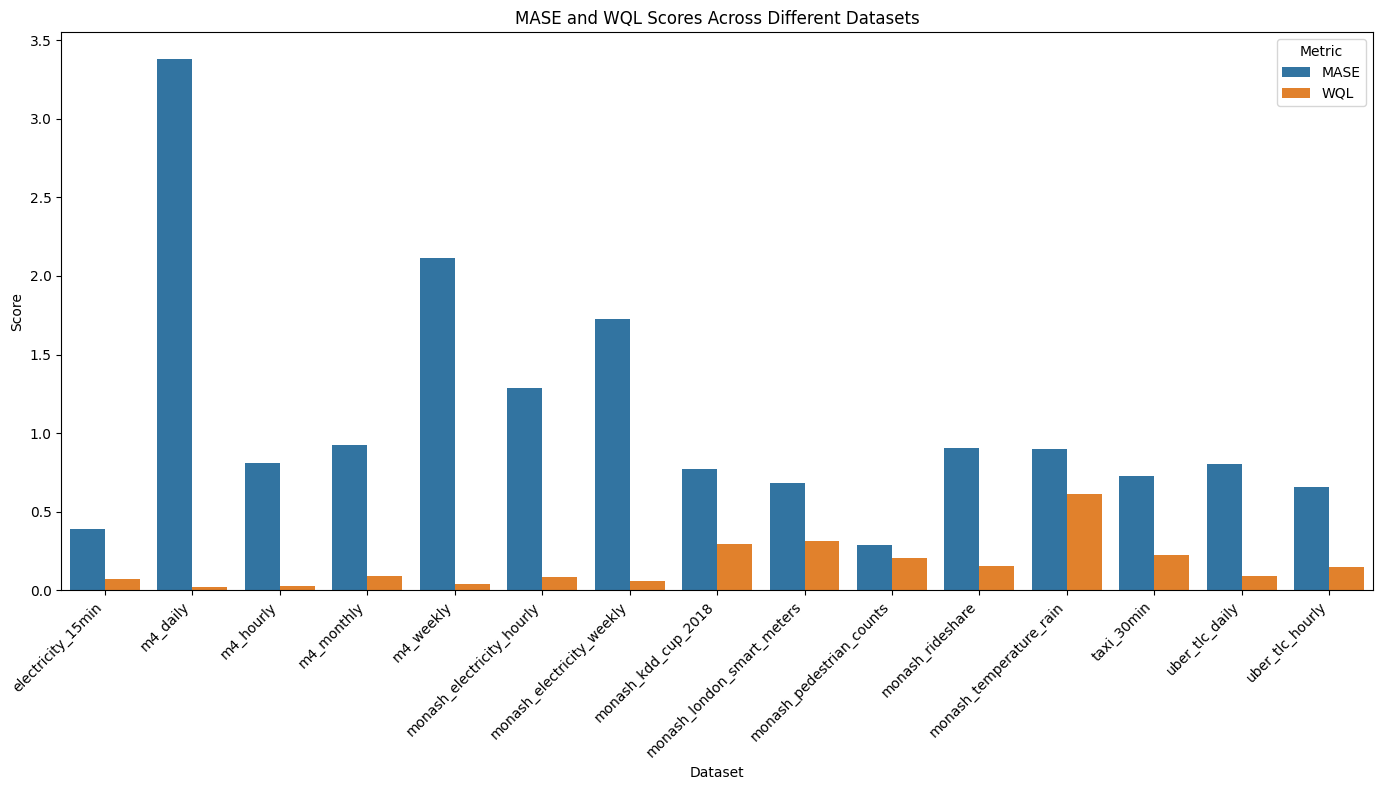

In [ ]:
# Melt the DataFrame to prepare for seaborn bar plot
melted_df = evaluation_results_df.melt(id_vars=['dataset', 'model'],
                                       value_vars=['MASE', 'WQL'],
                                       var_name='Metric',
                                       value_name='Score')

plt.figure(figsize=(14, 8))
sns.barplot(x='dataset', y='Score', hue='Metric', data=melted_df)
plt.title('MASE and WQL Scores Across Different Datasets')
plt.xlabel('Dataset')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

Full zero-shot evaluation (27 datasets)

In [ ]:
# ETTm and ETTh come from autogluon/chronos_datasets_extra which requires
# trust_remote_code=True (handled automatically in evaluate.py line 59)
!python scripts/evaluation/evaluate.py chronos-2 \
    scripts/evaluation/configs/zero-shot.yaml \
    scripts/evaluation/results/chronos-2-zero-shot.csv \
    --model-id "amazon/chronos-2" \
    --device cuda \
    --torch-dtype float32 \
    --batch-size 32

In [ ]:
import pandas as pd

zero_shot_evaluation_df = pd.read_csv('scripts/evaluation/results/chronos-2-zero-shot.csv')
display(zero_shot_evaluation_df)

,dataset,model,MASE,WQL
0,ETTh,amazon/chronos-2,0.760812,0.073566
1,ETTm,amazon/chronos-2,0.580035,0.045564
2,dominick,amazon/chronos-2,0.808580,0.324389
3,ercot,amazon/chronos-2,0.831767,0.025958
4,exchange_rate,amazon/chronos-2,1.852047,0.012116
5,m4_quarterly,amazon/chronos-2,1.200795,0.075973
6,m4_yearly,amazon/chronos-2,3.377616,0.117251
7,m5,amazon/chronos-2,0.905111,0.552674
8,monash_australian_electricity,amazon/chronos-2,0.629161,0.030728
9,monash_car_parts,amazon/chronos-2,0.833560,0.961073


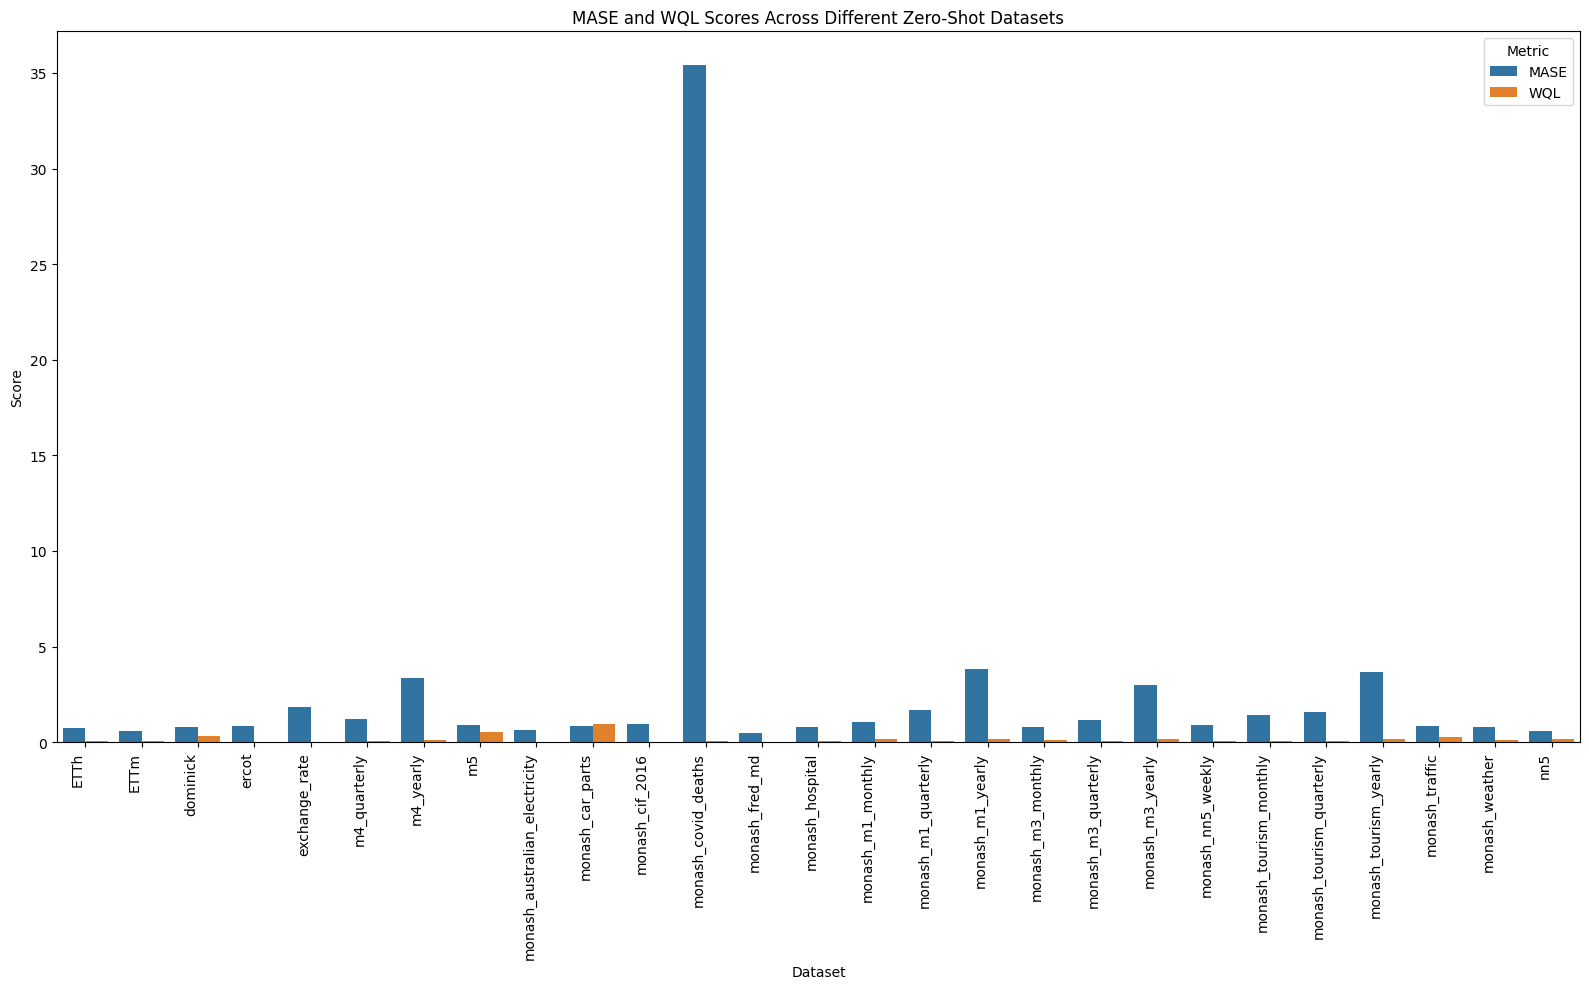

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame to prepare for seaborn bar plot
melted_zero_shot_df = zero_shot_evaluation_df.melt(id_vars=['dataset', 'model'],
                                                    value_vars=['MASE', 'WQL'],
                                                    var_name='Metric',
                                                    value_name='Score')

plt.figure(figsize=(16, 10)) # Increased figure size for more datasets
sns.barplot(x='dataset', y='Score', hue='Metric', data=melted_zero_shot_df)
plt.title('MASE and WQL Scores Across Different Zero-Shot Datasets')
plt.xlabel('Dataset')
plt.ylabel('Score')
plt.xticks(rotation=90, ha='right') # Rotate labels further for readability
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

In [ ]:
print('Average performance for In-Domain Evaluation:')
display(evaluation_results_df[['MASE', 'WQL']].mean().to_frame().T)

print('\nAverage performance for Zero-Shot Evaluation:')
display(zero_shot_evaluation_df[['MASE', 'WQL']].mean().to_frame().T)

Average performance for In-Domain Evaluation:


,MASE,WQL
0,1.090716,0.161788



Average performance for Zero-Shot Evaluation:


,MASE,WQL
0,2.613208,0.144556


From these tables, you can compare the average MASE and WQL for both evaluation types. Generally, a lower score indicates better performance.

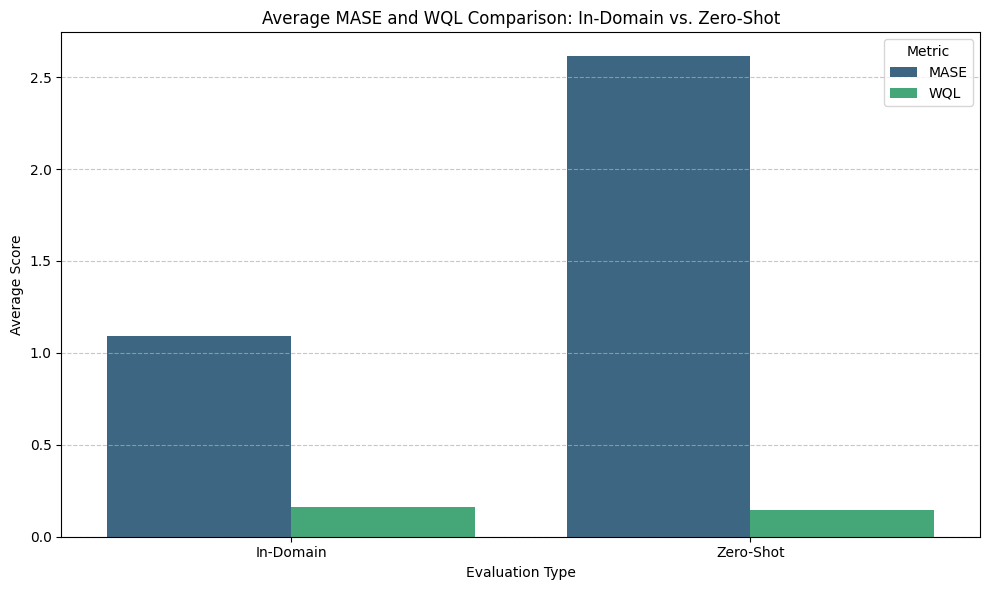

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate average MASE and WQL for In-Domain
avg_in_domain = evaluation_results_df[['MASE', 'WQL']].mean().to_frame().T
avg_in_domain['Evaluation_Type'] = 'In-Domain'

# Calculate average MASE and WQL for Zero-Shot
avg_zero_shot = zero_shot_evaluation_df[['MASE', 'WQL']].mean().to_frame().T
avg_zero_shot['Evaluation_Type'] = 'Zero-Shot'

# Concatenate the two average DataFrames
combined_avg_df = pd.concat([avg_in_domain, avg_zero_shot])

# Melt the combined DataFrame for plotting
melted_combined_avg_df = combined_avg_df.melt(id_vars=['Evaluation_Type'],
                                                value_vars=['MASE', 'WQL'],
                                                var_name='Metric',
                                                value_name='Average Score')

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Evaluation_Type', y='Average Score', hue='Metric', data=melted_combined_avg_df, palette='viridis')
plt.title('Average MASE and WQL Comparison: In-Domain vs. Zero-Shot')
plt.xlabel('Evaluation Type')
plt.ylabel('Average Score')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Compute aggregated relative scores (vs seasonal naive baseline)

In [ ]:
# Reproduces the "agg relative WQL/MASE" numbers in the paper
# Source: scripts/evaluation/agg-relative-score.py lines 10-16
!python scripts/evaluation/agg-relative-score.py \
    chronos-2 \
    --baseline-name seasonal-naive \
    --results-dir scripts/evaluation/results/
# Output: scripts/evaluation/results/chronos-2-agg-rel-scores.csv

In [ ]:
import pandas as pd
scores = pd.read_csv("scripts/evaluation/results/chronos-2-agg-rel-scores.csv")
display(scores)
# Columns: benchmark (in-domain/zero-shot), metric (MASE/WQL), value

,benchmark,metric,value
0,in-domain,MASE,0.690199
1,in-domain,WQL,0.543930
2,zero-shot,MASE,0.759321
3,zero-shot,WQL,0.575190


Evaluating a different model (Chronos-Bolt-base)

In [ ]:
!python scripts/evaluation/evaluate.py chronos-bolt \
    scripts/evaluation/configs/in-domain.yaml \
    scripts/evaluation/results/chronos-bolt-base-in-domain-new.csv \
    --model-id "amazon/chronos-bolt-base" \
    --device cuda \
    --torch-dtype bfloat16 \
    --batch-size 64   # Bolt is very fast; large batches are fine

In [ ]:
import pandas as pd

chronos_bolt_in_domain_df = pd.read_csv('scripts/evaluation/results/chronos-bolt-base-in-domain-new.csv')
display(chronos_bolt_in_domain_df)

,dataset,model,MASE,WQL
0,electricity_15min,amazon/chronos-bolt-base,0.411025,0.070779
1,m4_daily,amazon/chronos-bolt-base,3.208672,0.021135
2,m4_hourly,amazon/chronos-bolt-base,0.849375,0.025359
3,m4_monthly,amazon/chronos-bolt-base,0.950239,0.093847
4,m4_weekly,amazon/chronos-bolt-base,2.092386,0.038213
5,monash_electricity_hourly,amazon/chronos-bolt-base,1.255729,0.094393
6,monash_electricity_weekly,amazon/chronos-bolt-base,1.839545,0.064218
7,monash_kdd_cup_2018,amazon/chronos-bolt-base,0.640550,0.250930
8,monash_london_smart_meters,amazon/chronos-bolt-base,0.701415,0.321895
9,monash_pedestrian_counts,amazon/chronos-bolt-base,0.264440,0.187787


/tmp/ipykernel_2478/3665233697.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
/tmp/ipykernel_2478/3665233697.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')


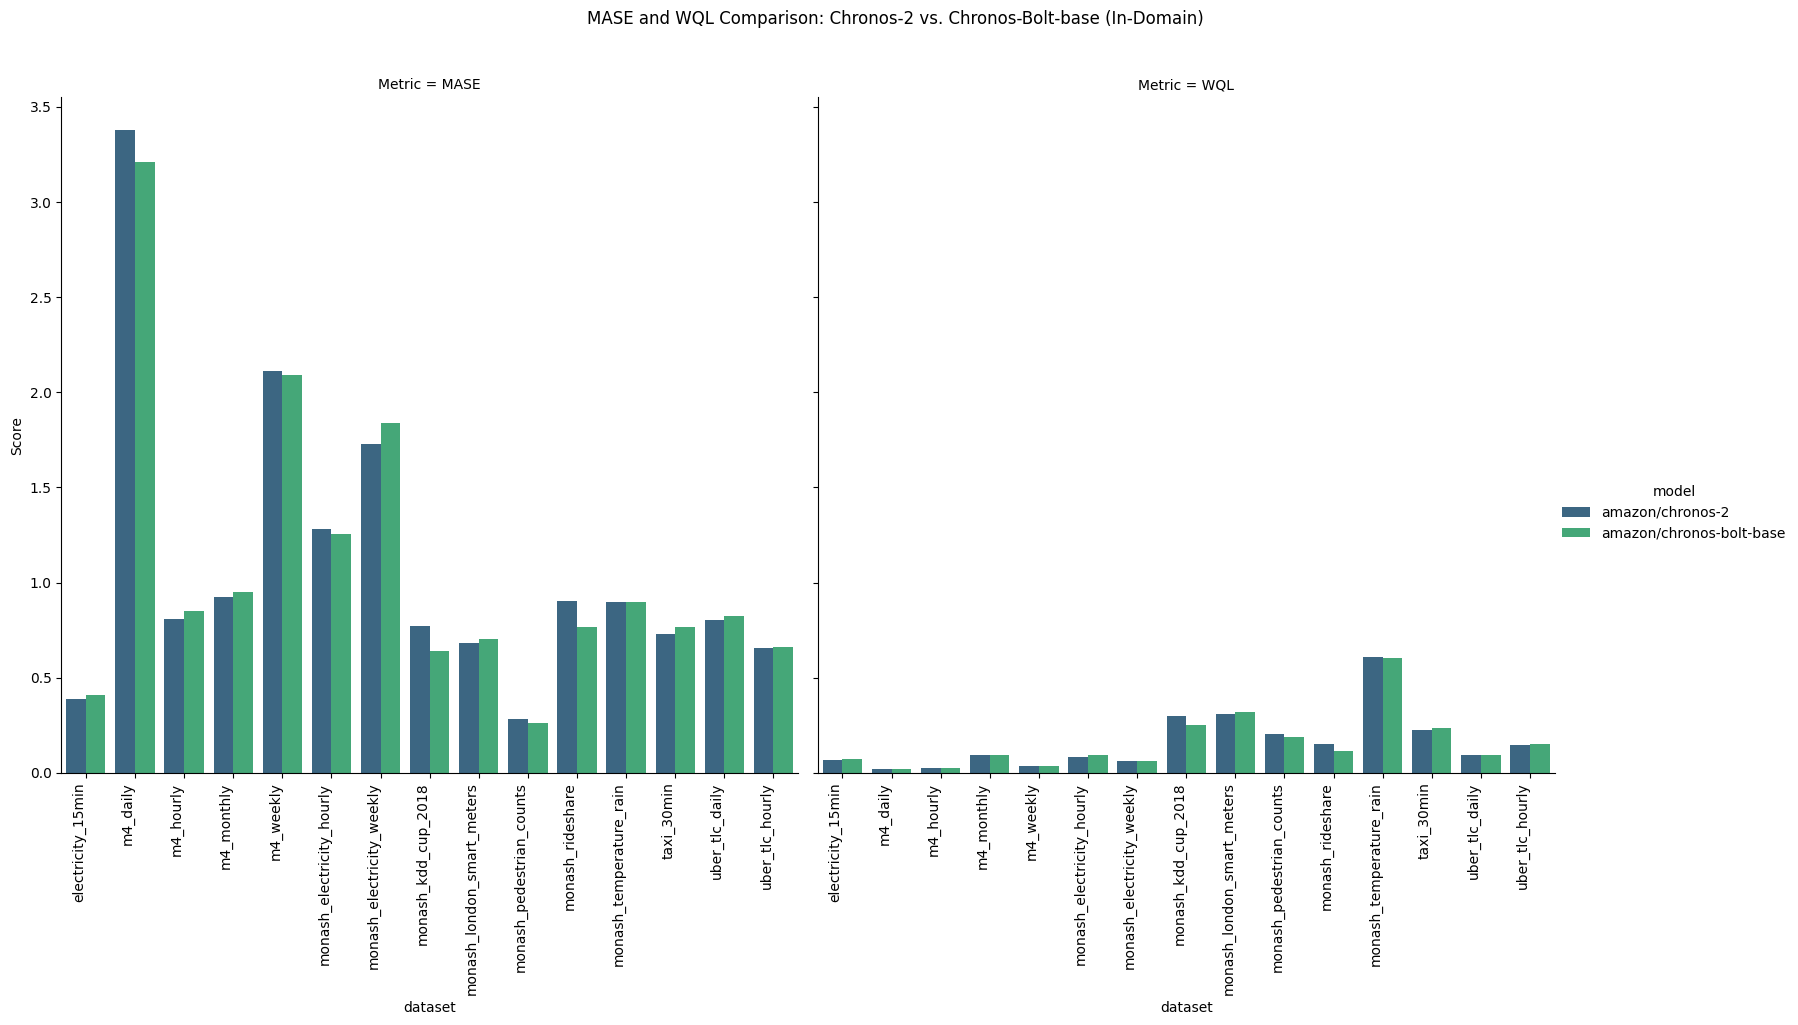

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine the in-domain evaluation results for Chronos-2 and Chronos-Bolt-base
# 'evaluation_results_df' contains Chronos-2 results
# 'chronos_bolt_in_domain_df' contains Chronos-Bolt-base results
combined_in_domain_df = pd.concat([evaluation_results_df, chronos_bolt_in_domain_df])

# Melt the combined DataFrame for plotting
melted_combined_in_domain_df = combined_in_domain_df.melt(id_vars=['dataset', 'model'],
                                                            value_vars=['MASE', 'WQL'],
                                                            var_name='Metric',
                                                            value_name='Score')

# Create the bar plot using sns.catplot for faceting
g = sns.catplot(
    x='dataset',
    y='Score',
    hue='model',
    col='Metric',
    data=melted_combined_in_domain_df,
    kind='bar', # Specify that we want a bar plot
    palette='viridis',
    col_wrap=2, # Wrap columns after 2 plots
    height=5, # Height of each facet
    aspect=1.8 # Aspect ratio of each facet
)

g.fig.set_size_inches(18, 10) # Set the overall figure size
g.fig.suptitle('MASE and WQL Comparison: Chronos-2 vs. Chronos-Bolt-base (In-Domain)', y=1.02) # Add a main title

# Rotate x-axis labels for each subplot
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')

g.tight_layout()
plt.show()

Evaluating original Chronos-T5-small

In [ ]:
!python scripts/evaluation/evaluate.py chronos \
    scripts/evaluation/configs/in-domain.yaml \
    scripts/evaluation/results/chronos-t5-small-in-domain-new.csv \
    --model-id "amazon/chronos-t5-small" \
    --device cuda \
    --torch-dtype bfloat16 \
    --batch-size 32 \
    --num-samples 20   # stochastic sampling; 20 trajectories

2026-04-26 20:49:16.341356: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777236556.389514   29777 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777236556.407693   29777 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777236556.459247   29777 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777236556.459290   29777 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777236556.459298   29777 computation_placer.cc:177] computation placer alr

In [ ]:
import pandas as pd

chronos_t5_in_domain_df = pd.read_csv('scripts/evaluation/results/chronos-t5-small-in-domain-new.csv')
display(chronos_t5_in_domain_df)

,dataset,model,MASE,WQL
0,electricity_15min,amazon/chronos-t5-small,0.414068,0.075746
1,m4_daily,amazon/chronos-t5-small,3.179577,0.022144
2,m4_hourly,amazon/chronos-t5-small,0.738127,0.025311
3,m4_monthly,amazon/chronos-t5-small,0.979060,0.106183
4,m4_weekly,amazon/chronos-t5-small,2.037136,0.040414
5,monash_electricity_hourly,amazon/chronos-t5-small,1.519588,0.113419
6,monash_electricity_weekly,amazon/chronos-t5-small,1.887232,0.083000
7,monash_kdd_cup_2018,amazon/chronos-t5-small,0.712640,0.297493
8,monash_london_smart_meters,amazon/chronos-t5-small,0.845060,0.440274
9,monash_pedestrian_counts,amazon/chronos-t5-small,0.301052,0.245793


/tmp/ipykernel_2478/2285641605.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
/tmp/ipykernel_2478/2285641605.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')


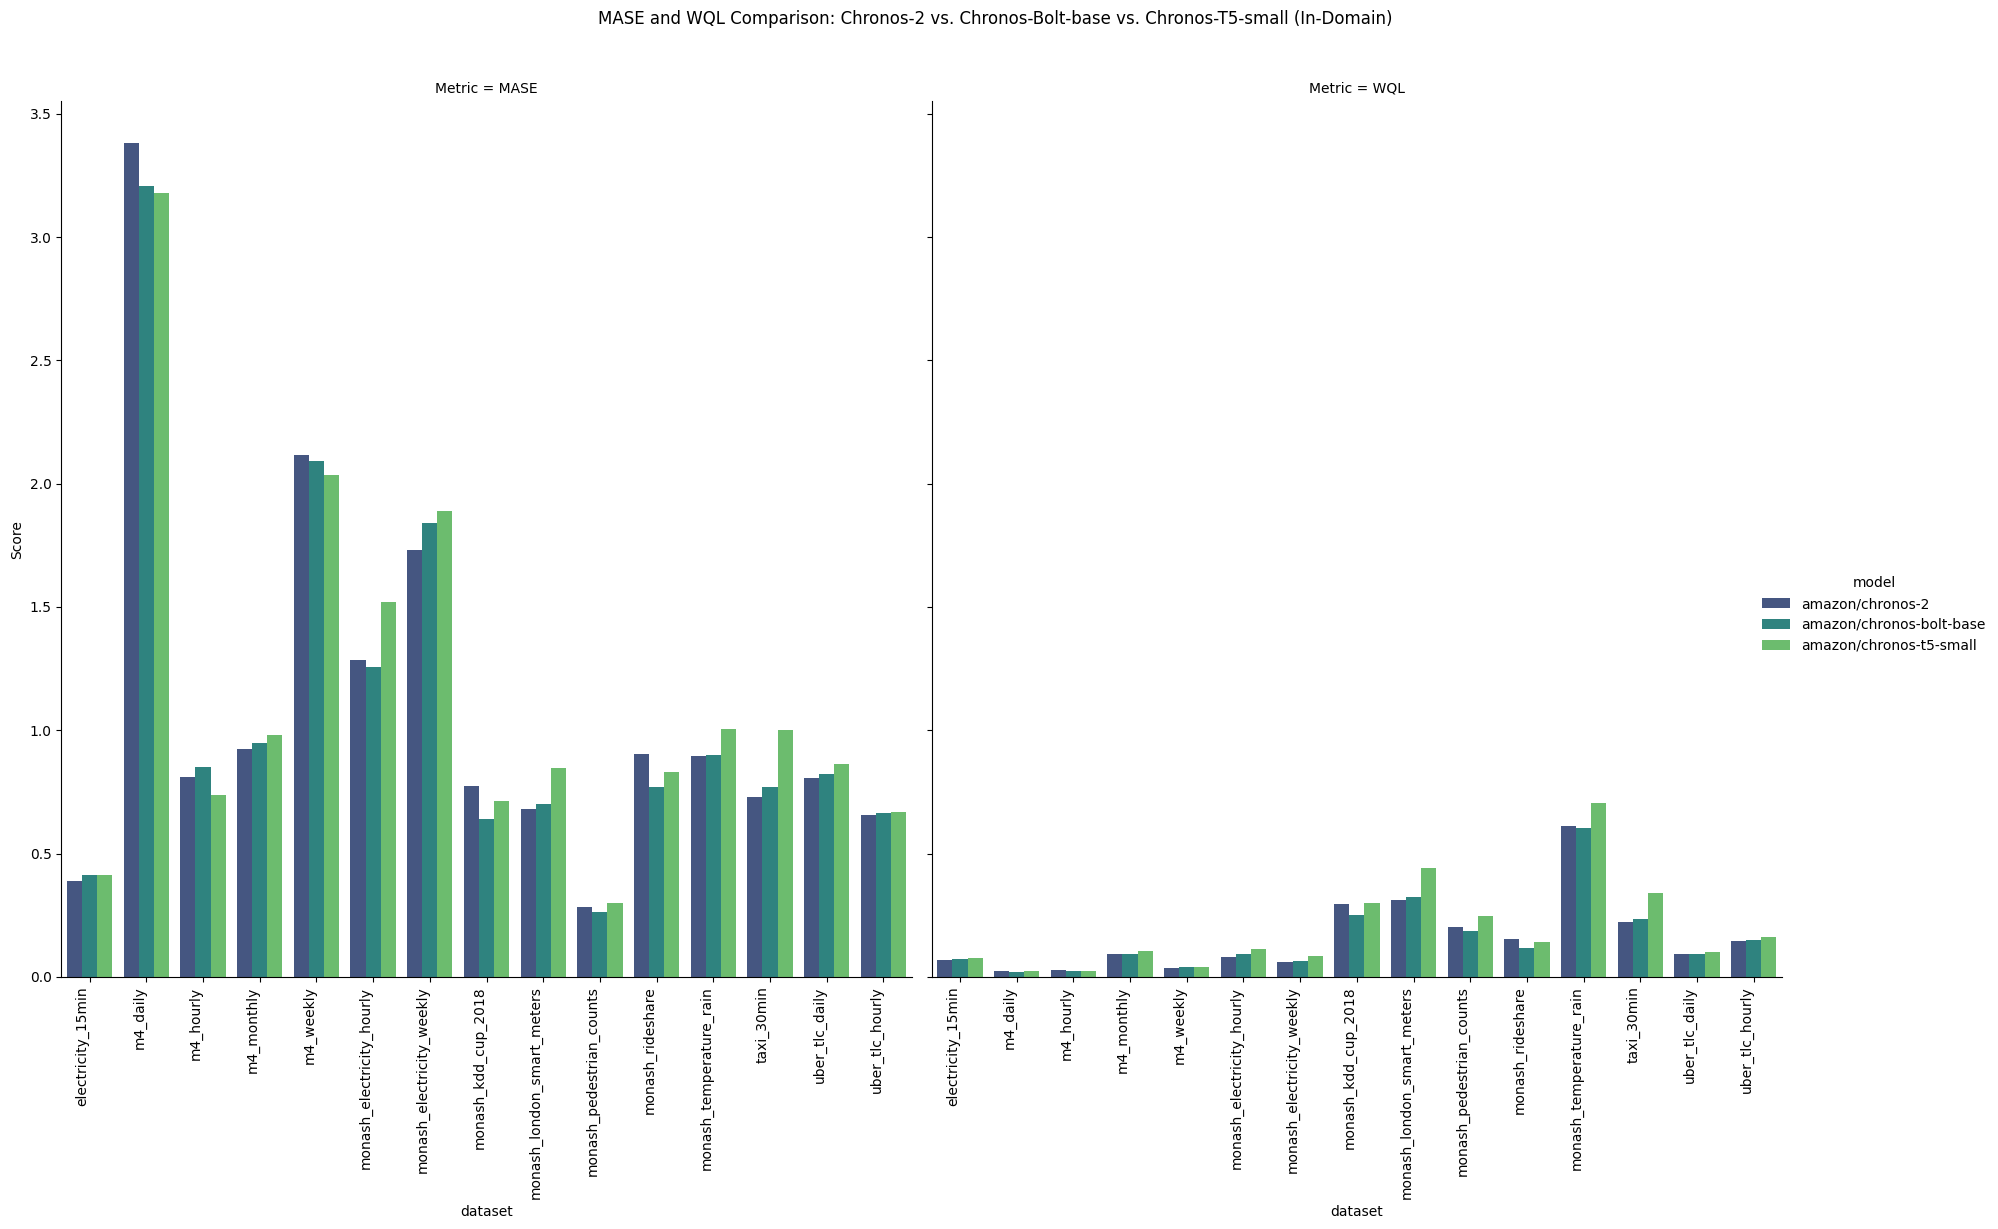

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine the in-domain evaluation results for all three models
# 'evaluation_results_df' contains Chronos-2 results
# 'chronos_bolt_in_domain_df' contains Chronos-Bolt-base results
# 'chronos_t5_in_domain_df' contains Chronos-T5-small results
combined_all_models_df = pd.concat([evaluation_results_df, chronos_bolt_in_domain_df, chronos_t5_in_domain_df])

# Melt the combined DataFrame for plotting
melted_all_models_df = combined_all_models_df.melt(id_vars=['dataset', 'model'],
                                                            value_vars=['MASE', 'WQL'],
                                                            var_name='Metric',
                                                            value_name='Score')

# Create the bar plot using sns.catplot for faceting
g = sns.catplot(
    x='dataset',
    y='Score',
    hue='model',
    col='Metric',
    data=melted_all_models_df,
    kind='bar',
    palette='viridis',
    col_wrap=2,
    height=6,
    aspect=2
)

g.fig.set_size_inches(20, 12) # Set the overall figure size
g.fig.suptitle('MASE and WQL Comparison: Chronos-2 vs. Chronos-Bolt-base vs. Chronos-T5-small (In-Domain)', y=1.02) # Add a main title

# Rotate x-axis labels for each subplot
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')

g.tight_layout()
plt.show()